UMBRALIZACION


UMBRALIZACION CON LA TECNICA DE ISO DATA


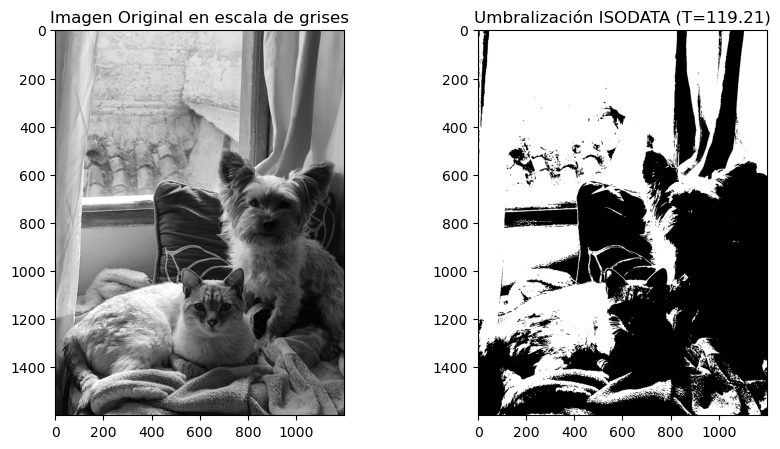

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def isodata (imagen):
    umbral = 128
    while True:
        grupo1=imagen [imagen<=umbral]
        grupo2=imagen [imagen>=umbral]
        
        mediag1=np.mean(grupo1)
        mediag2=np.mean(grupo2)
        
        umbral_nuevo = (mediag1+mediag2)/2
        
        if abs(umbral_nuevo-umbral)< 0.5:
            break
        umbral=umbral_nuevo
        
    return umbral

imagen= cv2.imread('imagentango.jpg',0)

umbral_isodata = isodata(imagen)

umbral_isodata = isodata(imagen)

_, imagen_isodata=cv2.threshold (imagen, umbral_isodata, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Imagen Original en escala de grises")
plt.imshow(imagen, cmap = 'gray')

plt.subplot(1,2,2)
plt.imshow(imagen_isodata, cmap='gray')
plt.title(f"Umbralización ISODATA (T={umbral_isodata:.2f})")
plt.show()

UMBRALIZACION POR TECNICA DE 2 PICOS

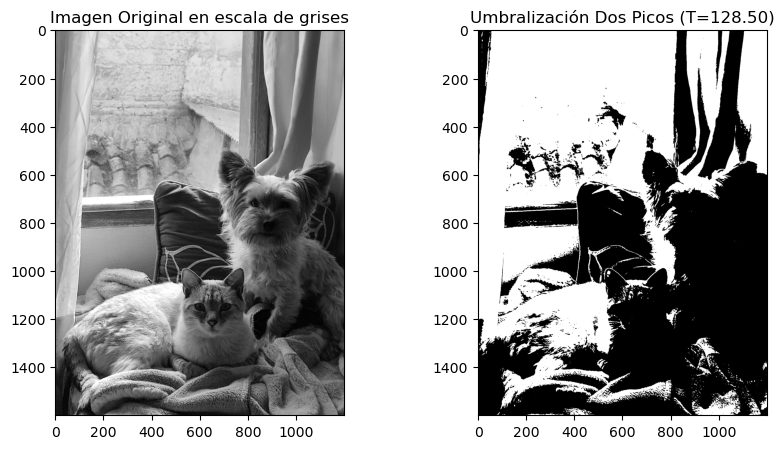

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(imagen):
    hist= cv2.calcHist ([imagen], [0], None, [256], [0,256])
    pico=np.array(hist)
    pico=pico.flatten()
    pico_dif=np.diff(pico)
    primer_pico= np.argmax(pico_dif[:128])
    segundo_pico= np.argmax(pico_dif[128:])+128
    umbral_2picos= ((primer_pico+segundo_pico)/2)
    return umbral_2picos

image= cv2.imread('imagentango.jpg',0)

umbral_2pic=dos_picos(imagen)

_, imagen_2picos=cv2.threshold(image, umbral_2pic, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Imagen Original en escala de grises")
plt.imshow(image, cmap = 'gray')

plt.subplot(1,2,2)
plt.imshow(imagen_2picos, cmap='gray')
plt.title(f"Umbralización Dos Picos (T={umbral_2pic:.2f})")
plt.show()

   

UMBRALIZACION METODO OTSU

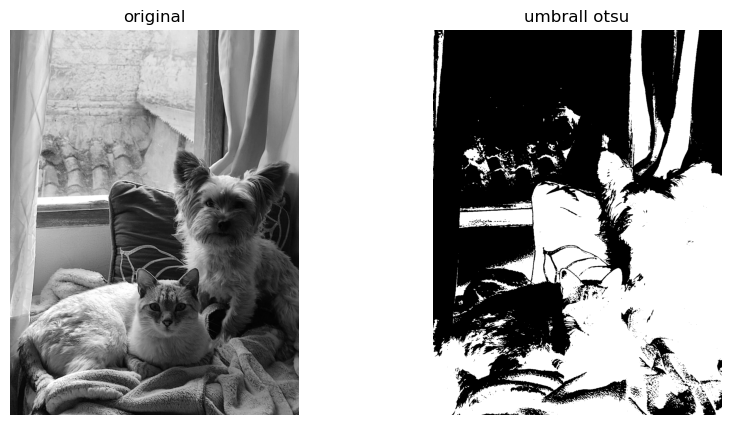

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen= cv2.imread('imagentango.jpg',0)

_,imagenOtsu=cv2.threshold(imagen,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
umbral_imagen=np.where(imagen>imagenOtsu,255,0).astype(np.uint8)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original")
plt.axis("off")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("umbrall otsu")
plt.imshow(umbral_imagen,cmap="gray")
plt.axis("off")
plt.show()

UMBRALIZACION VARIABLE - PARTICION DE UNA IMAGEN

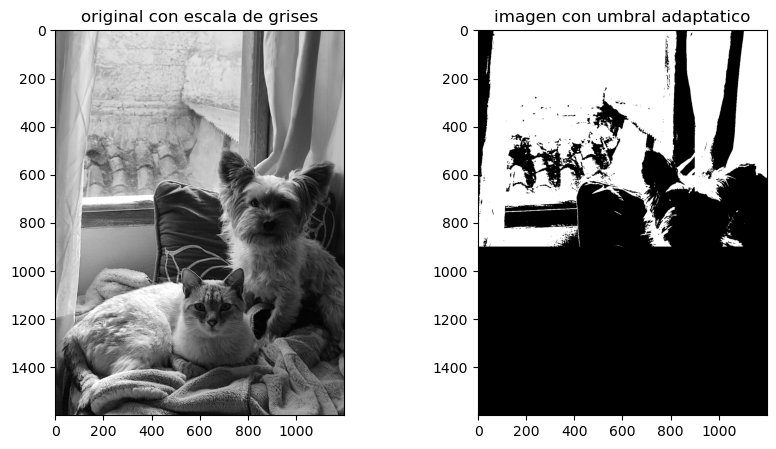

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_umb_blok(image, tam_bloq, c):
    umbral_ima=np.zeros_like(image)
    for y in range (0, image.shape[0], tam_bloq):
        for x in range (0, image.shape[1], tam_bloq):
            bloque= image[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media=np.mean(bloque)
            umbral_adap=bloque_media-c
            umbral_ima[y:y+tam_bloq, x:x+tam_bloq]=(bloque>umbral_adap)*255 
    
        return umbral_ima
    
imagen= cv2.imread('imagentango.jpg',0)
tam_bloq = 900
c = 10
umbral_img_adap=variable_umb_blok(imagen, tam_bloq, c)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original con escala de grises")
plt.axis("on")
plt.imshow(imagen,cmap="gray")

plt.subplot(1,2,2)
plt.title("imagen con umbral adaptatico")
plt.imshow(umbral_img_adap, cmap="gray")
plt.axis("on")
plt.show()
            

CON DESVIACION

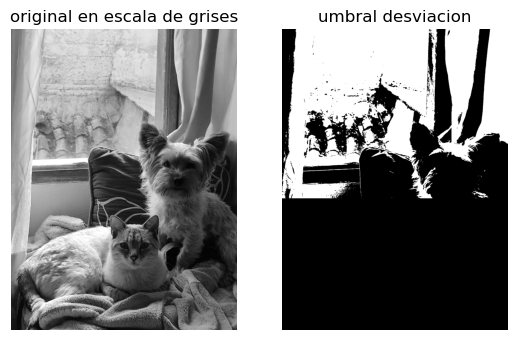

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def umbra_var2 (imagen, tam_bloq, ajuste):
    umbral_ima=np.zeros_like(image)
    for y in range(0, image.shape[0], tam_bloq):
        for x in range (0, image.shape[1], tam_bloq):
            bloque= image[y:y+tam_bloq,x:x+tam_bloq]
            bloque_media=np.mean(bloque)
            des=np.std(bloque)
            umbral_adap=bloque_media-(ajuste*des)
            umbral_ima[y:y+tam_bloq, x:x+tam_bloq]=(bloque>umbral_adap)*255 
        return umbral_ima
    
    
imagen= cv2.imread('imagentango.jpg',0)
tam_bloq = 900
c = 0.8
umbral_=variable_umb_blok(imagen, tam_bloq, c)


plt.subplot(1,2,1)
plt.title("original en escala de grises")
plt.axis("off")
plt.imshow(imagen,cmap="gray")



plt.subplot(1,2,2)
plt.title("umbral desviacion")
plt.imshow(umbral_,cmap="gray")
plt.axis("off")
plt.show()

adaptativa con ventana

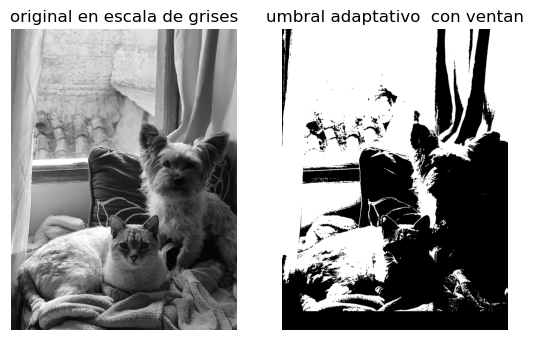

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def ventana (imagen, ventana, factor):
    umbre_imagen=np.zeros_like(imagen)
    pad=ventana//2
    padd_imge=cv2.copyMakeBorder(imagen, pad, pad, pad, pad, cv2.BORDER_REPLICATE)
    
    for y in range(imagen.shape[0]):
        for x in range (imagen.shape[1]):
            ventana1= padd_imge[y:y+ventana, x:x+ventana]
            media= np.mean(ventana1)
            dis= np.std(ventana1)
            umbral=media - (factor*dis)
            umbre_imagen [y,x]=255 if imagen[y,x] > umbral else 0
        return umbre_imagen
    
imagen= cv2.imread('imagentango.jpg',0)
tam_bloq = 1500
c = 2
umbral =variable_umb_blok(imagen, tam_bloq, c)

plt.subplot(1,2,1)
plt.title("original en escala de grises")
plt.axis("off")
plt.imshow(imagen,cmap="gray")



plt.subplot(1,2,2)
plt.title("umbral adaptativo  con ventan")
plt.imshow(umbral,cmap="gray")
plt.axis("off")
plt.show()

    

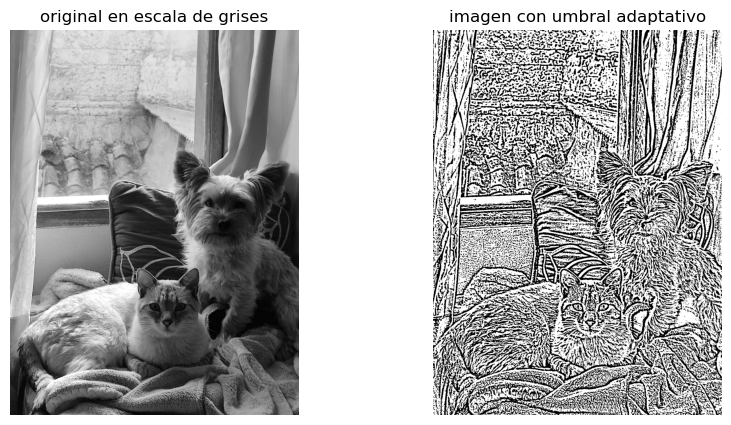

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen= cv2.imread('imagentango.jpg',0)
ventana=15
factor=2
imagen_umbr= cv2.adaptiveThreshold(image,255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, factor)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("original en escala de grises")
plt.axis("off")
plt.imshow(imagen,cmap="gray")


plt.subplot(1,2,2)
plt.title("imagen con umbral adaptativo")
plt.imshow(imagen_umbr,cmap="gray")
plt.axis("off")
plt.show()